In [4]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

# 0. 한글 폰트 및 그래프 마이너스 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

In [16]:
# ==========================================
# 1. 데이터 로드
# ==========================================
train = pd.read_csv('train_preprocessed_ff.csv')
test_df = pd.read_csv('test_preprocessed_ff.csv') # 기존 변수명 test와 겹치지 않게 변경

# 독립변수(X)와 종속변수(y) 분리
target_col = '임신 성공 여부'
X = train.drop(columns=[target_col])
y = train[target_col]

# 학습용 / 검증용 데이터 분할 (8:2)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# ==========================================
# 2. [수정 반영] 범주형 변수 문자열 변환 후 category 타입 지정
# ==========================================
categorical_cols = [
    "시술 당시 나이",
    "시술 유형",
    "배아 생성 주요 이유",
    "난자 출처",
    "정자 출처",
    "난자 기증자 나이",
    "정자 기증자 나이"
]

# 숫자로 된 범주형 변수들을 str로 확실히 묶은 뒤 category로 변환합니다.
for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('Int64').astype(str).replace('nan', pd.NA).astype('category')
    if col in X_valid.columns:
        X_valid[col] = X_valid[col].astype('Int64').astype(str).replace('nan', pd.NA).astype('category')
    if col in test_df.columns:
        test_df[col] = test_df[col].astype('Int64').astype(str).replace('nan', pd.NA).astype('category')

print(" 데이터 준비 및 안전한 category 타입 변환 완료!")
print(f"학습 데이터 크기: {X_train.shape}, 검증 데이터 크기: {X_valid.shape}\n")

 데이터 준비 및 안전한 category 타입 변환 완료!
학습 데이터 크기: (205080, 68), 검증 데이터 크기: (51271, 68)



In [18]:
# ==========================================
# 3. 1차 모델링 (기본 LightGBM Classifier 생성 및 학습)
# ==========================================
print("🚀 [1차 모델링] 기본 LightGBM Classifier 생성 중...")
# 튜닝 없는 가장 정직한 기본 패션 세팅
base_clf = LGBMClassifier(
    random_state=42,
    verbose=-1
)

# 1차 모델 학습 시작
base_clf.fit(X_train, y_train)
print("1차 모델링 학습 완료!\n")

🚀 [1차 모델링] 기본 LightGBM Classifier 생성 중...
1차 모델링 학습 완료!



In [19]:
# ==========================================
# 4. 전체 데이터 세트 최종 성능 평가 (1차 기준점)
# ==========================================
y_pred = base_clf.predict(X_valid)
# ROC-AUC를 위한 성공(1) 확률 값 추출
pred_proba = base_clf.predict_proba(X_valid)[:, 1]

# 각 평가지표 계산
test_accuracy = accuracy_score(y_valid, y_pred)
auc = roc_auc_score(y_valid, pred_proba)

print("=== 최종 성능 평가 결과 ===")
print(f"🥇 정확도 (Accuracy): {test_accuracy:.4f}")
print(f"📈 ROC-AUC Score: {auc:.5f}") # 요청하신 소수점 5자리 출력 반영

print("\n--- 전체 검증 데이터 Classification Report ---")
print(classification_report(y_valid, y_pred))

=== 최종 성능 평가 결과 ===
🥇 정확도 (Accuracy): 0.7450
📈 ROC-AUC Score: 0.73571

--- 전체 검증 데이터 Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     38025
           1       0.53      0.10      0.17     13246

    accuracy                           0.75     51271
   macro avg       0.65      0.54      0.51     51271
weighted avg       0.70      0.75      0.67     51271



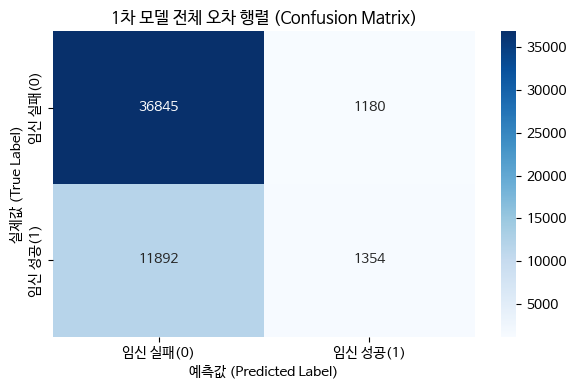

In [20]:
# ==========================================
# 5. 전체 오차 행렬 (Confusion Matrix) 시각화
# ==========================================
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['임신 실패(0)', '임신 성공(1)'],
            yticklabels=['임신 실패(0)', '임신 성공(1)'])
plt.title('1차 모델 전체 오차 행렬 (Confusion Matrix)')
plt.ylabel('실제값 (True Label)')
plt.xlabel('예측값 (Predicted Label)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

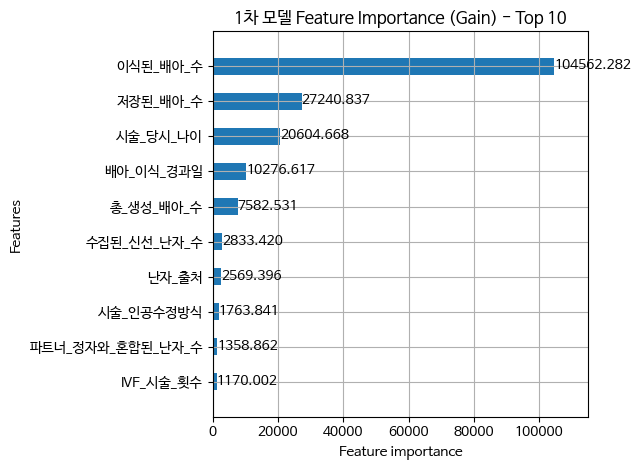

In [21]:
# ==========================================
# 6. 1차 모델 피처 중요도 (Gain 기준) 시각화
# ==========================================
plt.figure(figsize=(10, 6))
plot_importance(base_clf, max_num_features=10, importance_type='gain', height=0.5)
plt.title("1차 모델 Feature Importance (Gain) - Top 10")
plt.tight_layout()
plt.show()

In [22]:
# ==========================================
# 6. 피처 중요도 데이터프레임 생성 및 CSV 파일 추출 (요청 반영)
# ==========================================
# Gain 기준으로 피처 중요도 점수 추출
importances = base_clf.booster_.feature_importance(importance_type='gain')
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 데이터프레임으로 정렬하여 만들기
feature_importance = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n📋 피처 중요도 상위 10개 테이블:")
print(feature_importance.head(10).to_string(index=False))

# 요청하신 형식대로 엑셀에서 한글이 깨지지 않게 utf-8-sig로 저장합니다.
feature_importance.to_csv(
    "LGBM_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)
print("\n💾 'LGBM_feature_importance.csv' 파일 저장 완료!")


📋 피처 중요도 상위 10개 테이블:
         Feature    Importance
        이식된 배아 수 104562.281817
        저장된 배아 수  27240.836765
        시술 당시 나이  20604.668482
       배아 이식 경과일  10276.617383
       총 생성 배아 수   7582.531377
     수집된 신선 난자 수   2833.420346
           난자 출처   2569.395791
       시술_인공수정방식   1763.841003
파트너 정자와 혼합된 난자 수   1358.862288
       IVF 시술 횟수   1170.002160

💾 'LGBM_feature_importance.csv' 파일 저장 완료!
